# Notebook 04 - Regime detection and regime-adaptive filtering (HMM + switching Kalman filter)

This notebook produces the main modelling result. It fits a three-state hidden Markov model to per-minute order-book features, then uses the inferred regimes to drive a Kalman filter whose noise settings change with the market state. The regime-adaptive filter is compared against a naive martingale and a static Kalman filter on a held-out test set.

The notebook runs from the fixed input market_data.csv and tracks the Match Odds favourite in each event. It works in two stages: first a three-state Gaussian HMM labels each minute as Static_Illiquid, Normal_Trading, or Volatile_Shock; then a local-level-plus-trend Kalman filter tracks the log-odds price with its process and measurement noise switching by regime.

The reported test-set RMSEs (probability scale) are: naive 0.0641, static KF 0.0588, switching KF strict 0.0579, switching KF nowcast 0.0563. The regime-adaptive filter gives a small, consistent improvement over the static filter, confirmed by a five-fold walk-forward check. A non-causal oracle (regimes known in advance) puts the ceiling at about 11.7%, so most of the achievable gain depends on knowing the regime ahead of time; the deployable causal gain is modest.

To reproduce, place market_data.csv at ../data/raw/ and run all cells in order. Requires hmmlearn, scikit-learn, scipy, and statsmodels. Figures and tables are written to ../outputs/04_hmm_kalman_analysis/.

## 1. Configuration and reproducibility

Fixes the random seed, resolves the input path (and stops early if market_data.csv is missing), creates the output folders, and writes a run-metadata file.

In [1]:
"""
Configuration and Reproducibility Setup
========================================
This cell configures paths, random seeds, and output directories.
The data path can be set via environment variable or uses a default relative path.
"""

import os
import sys
import json
from pathlib import Path
from datetime import datetime, timezone
import random
import numpy as np

# Configuration

SEED = 42
NOTEBOOK_NAME = "04_hmm_kalman_analysis"

# Random seeds for reproducibility

random.seed(SEED)
np.random.seed(SEED)

# Data Path
DATA_PATH = Path("../data/raw/market_data.csv")

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Data file not found at: {DATA_PATH.resolve()}\n"
        "Place market_data.csv in ../data/raw/ (see README)."
    )

# Output Directories

OUTPUT_DIR = Path(f"../outputs/{NOTEBOOK_NAME}")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_OUT_DIR = OUTPUT_DIR / "data" 

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUT_DIR.mkdir(parents=True, exist_ok=True)


# Run Metadata

metadata = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "notebook": NOTEBOOK_NAME,
    "seed": SEED,
    "python_version": sys.version.split()[0],
    "data_file": DATA_PATH.name
}

with open(OUTPUT_DIR / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Data path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Random seed: {SEED}")

Data path: ..\data\raw\market_data.csv
Output directory: ..\outputs\04_hmm_kalman_analysis
Random seed: 42


## 2. Libraries, constants, and helpers

Imports the analysis stack plus the three model-specific tools: GaussianHMM (hmmlearn) for regime detection, StandardScaler (scikit-learn) to standardise features before fitting, and logsumexp (scipy) for the numerically stable forward algorithm used later.

In [2]:
"""
Library Imports and Plot Settings
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.special import logsumexp

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [3]:
"""
Constants used throughout the notebook
"""

CORE_MARKETS = [
    "Match Odds",
    "Over/Under 2.5 Goals",
    "Both teams to Score?"
]

MARKET_CODE_MAP = {
    "Match Odds": "MO",
    "Over/Under 2.5 Goals": "OU25",
    "Both teams to Score?": "BTTS"
}

In [4]:

"""
Output Helper Functions
"""

def save_figure(name, fig=None):
    """Save figure as both PNG and PDF."""
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig = fig or plt.gcf()

    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"

    fig.savefig(png_path, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved: {png_path.name}, {pdf_path.name}")
    return png_path, pdf_path


def save_table(df, name, index=False):
    """Save DataFrame as both CSV and LaTeX."""
    TABLE_DIR.mkdir(parents=True, exist_ok=True)

    csv_path = TABLE_DIR / f"{name}.csv"
    tex_path = TABLE_DIR / f"{name}.tex"

    df.to_csv(csv_path, index=index)
    df.to_latex(tex_path, index=index, float_format="%.4f")

    print(f"Saved: {csv_path.name}, {tex_path.name}")
    return csv_path, tex_path


## 3. Loading the data

Reads the CSV, checks the required columns are present, parses the timestamps as UTC, keeps pre-match rows only, computes time-to-kick-off (tau), and restricts to the final 360 minutes before kick-off.

In [5]:
# Load Data
print("Loading data...")
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

required = {
    'event_id', 'ts_utc', 'market_time', 'market_name',
    'selection_name', 'best_back_price', 'best_lay_price'
    }
missing = required - set(df.columns)
if missing:
    raise KeyError(f"Missing required columns: {sorted(missing)}")

# Convert Timestamps
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True, errors="coerce")
df["market_time"] = pd.to_datetime(df["market_time"], utc=True, errors="coerce")
df = df.dropna(subset=["ts_utc", "market_time"])

# Filter pre-match Window (0 to 6 hours before kickoff)
df = df[df["ts_utc"] < df["market_time"]].copy()
df["tau_minutes"] = (df["market_time"] - df["ts_utc"]).dt.total_seconds() / 60.0
df = df[df["tau_minutes"].between(0, 360)].copy()

print(f"Data Loaded. Shape: {df.shape}. Unique Events: {df['event_id'].nunique()}")

Loading data...
Data Loaded. Shape: (11384468, 14). Unique Events: 290


## 4. Feature engineering

These two functions turn one event's raw ticks into the per-minute feature matrix the HMM uses. The model tracks the favourite in Match Odds, identified as the selection with the lowest mean odds.

get_clean_event_panel builds the minute panel. A best quote with a displayed size of zero is set to missing before any forward-fill, since it is not actually tradable. Prices are pivoted wide, resampled to one-minute bars (last value), and forward-filled to represent the standing quote. The mid is taken in odds space, the favourite is identified, and its mid is converted to the log-odds of the implied probability (clipped just inside zero and one). The per-minute update count is kept as an activity measure, and the panel is restricted to tau in the 0 to 360 minute window.

get_robust_features builds the three model features from that panel: the relative bid-ask spread (clipped at 0.50 so a few extreme illiquid values do not dominate the scaling), a compressed volatility measure from the log-odds return, and the log of the per-minute update count.

In [6]:
# Define the Robust Transformation Function
def get_clean_event_panel(df_all, event_id, freq='1min'):
    # Filter & Sort
    df = df_all[df_all['event_id'] == event_id].copy()
    df = df.sort_values('ts_utc')
    df = df[df['market_name'] == 'Match Odds']
    
    if df.empty: return None

    # Ghost liquidity
    # If the best quote has size==0, it is not actually available to trade.
    # Invalidate the associated price before pivot/resample/ffill to avoid carrying phantom quotes forward.

    # Make sure size columns (if present) are numeric
    if 'best_back_size' in df.columns:
        df['best_back_size'] = pd.to_numeric(df['best_back_size'], errors='coerce')
    if 'best_lay_size' in df.columns:
        df['best_lay_size'] = pd.to_numeric(df['best_lay_size'], errors='coerce')

    # Invalidate prices where displayed size is zero or negative
    if {'best_back_price', 'best_back_size'}.issubset(df.columns):
        df.loc[df['best_back_size'] <= 0, 'best_back_price'] = np.nan

    if {'best_lay_price', 'best_lay_size'}.issubset(df.columns):
        df.loc[df['best_lay_size'] <= 0, 'best_lay_price'] = np.nan

    # Pivot
    df['runner'] = df['selection_name']
    pivot_back = df.pivot_table(index='ts_utc', columns='runner', values='best_back_price', aggfunc='last')
    pivot_lay = df.pivot_table(index='ts_utc', columns='runner', values='best_lay_price', aggfunc='last')
    
    # Resample (Grid)
    df_back = pivot_back.resample(freq).last()
    df_lay = pivot_lay.resample(freq).last()

    # 0's to NaN to prserve actual prices when ffill
    df_back = df_back.replace(0, np.nan)
    df_lay = df_lay.replace(0, np.nan)

    # Forward Fill 
    df_back = df_back.ffill()
    df_lay = df_lay.ffill()

    # Mid Price & Spread
    mid_price = (df_back + df_lay) / 2.0
    
    # Calculate relative spread
    spread_rel = (df_lay - df_back) / df_back
    
    # Identify Favorite
    if mid_price.isna().all().all(): return None
    mean_odds = mid_price.mean()
    fav_name = mean_odds.idxmin()
    
    # Features
    prob = (1.0 / mid_price[fav_name]).clip(0.001, 0.999)
    log_odds = np.log(prob / (1 - prob))
    
    activity = df.set_index('ts_utc').resample(freq)['event_id'].count()
    
    # Create Panel
    panel = pd.DataFrame({
        'log_odds': log_odds,
        'spread_rel': spread_rel[fav_name],
        'tick_count': activity
    })
    
    # Standard clean
    panel = panel.dropna(subset=['log_odds'])
    panel = panel.reset_index() # Ensure ts_utc is a column
    
    # Time Filters
    market_time = df['market_time'].iloc[0]
    panel['tau_min'] = (market_time - panel['ts_utc']).dt.total_seconds() / 60
    panel = panel[(panel['tau_min'] > 0) & (panel['tau_min'] <= 360)]
    
    return panel

In [7]:
#  Feature Engineering
def get_robust_features(df_raw, event_id, freq='1min'):
    # Get Panel - includes wide spreads/illiquidity)
    panel = get_clean_event_panel(df_raw, event_id, freq)
    
    if panel is None or len(panel) < 50:
        return None

    # Clip Spreads 
    panel['spread_rel'] = panel['spread_rel'].clip(upper=0.50)
    
    # Calculate Returns
    panel['log_odds'] = panel['log_odds'].ffill()
    panel['return'] = panel['log_odds'].diff().fillna(0)
    
    # If the spread is > 20%, assume the "price change" is just noise.
    # We force return to 0, but we keep the high spread value.
    mask_illiquid = panel['spread_rel'] > 0.20
    panel.loc[mask_illiquid, 'return'] = 0.0
    
    # Volatility
    panel['log_vol'] = np.log1p(panel['return'].abs() * 100)
    
    # Activity
    if 'tick_count' in panel.columns:
        panel = panel[panel['tick_count'] > 0].copy()
        panel['log_tick_count'] = np.log1p(panel['tick_count'])
    
    # Final Cleanup
    panel = panel.replace([np.inf, -np.inf], np.nan).ffill()
    
    return panel

## 5. Chronological train / validation / test split

Events are ordered by kick-off time and split 70/30 into train and test by time, so every training event kicks off before every test event and the model is never evaluated on a period it was fitted on. The last 50 training events are held out as a validation set for tuning, leaving a training core for fitting. The asserts make the guarantees explicit: train and test do not overlap, validation is a subset of train, and the latest training kick-off is no later than the earliest test kick-off. All later tuning uses the validation set; the test set is used once at the end.

In [8]:
# Event split chronological by kickoff


print("Establishing chronological event split...")

# One kickoff timestamp per event use earliest market_time seen for that event
event_meta = (
    df[["event_id", "market_time"]]
    .dropna()
    .groupby("event_id", as_index=False)["market_time"]
    .min()
    .sort_values("market_time")
    .reset_index(drop=True)
)

sorted_event_ids = event_meta["event_id"].to_numpy()
n_events = len(sorted_event_ids)

# Train/test split by time (70/30)
train_frac = 0.70
n_train = int(np.floor(train_frac * n_events))

train_ids = set(sorted_event_ids[:n_train])
test_ids  = set(sorted_event_ids[n_train:])

# Validation split inside train: last 50 training events 
n_val = min(50, n_train)
val_start = max(0, n_train - n_val)

val_ids = set(sorted_event_ids[val_start:n_train])
train_core_ids = train_ids - val_ids

# Alias
validation_ids = val_ids

# Basic consistency checks
assert train_ids.isdisjoint(test_ids), "Train/Test overlap!"
assert val_ids.issubset(train_ids), "Validation not subset of train!"
assert train_core_ids.isdisjoint(val_ids), "Train core overlaps validation!"
assert len(train_ids) + len(test_ids) == n_events, "Split size mismatch!"

train_max_time = event_meta.loc[event_meta["event_id"].isin(train_ids), "market_time"].max()
test_min_time  = event_meta.loc[event_meta["event_id"].isin(test_ids),  "market_time"].min()
assert train_max_time <= test_min_time, "Chronological split violated!"

# Summary
print(f"TOTAL events: {n_events}")
print(f"TRAIN events: {len(train_ids)} (core={len(train_core_ids)} + val={len(val_ids)})")
print(f"TEST  events: {len(test_ids)}")

print("\nKickoff time ranges:")
print(
    "Train:",
    event_meta.loc[event_meta["event_id"].isin(train_ids), "market_time"].min(),
    "to",
    event_meta.loc[event_meta["event_id"].isin(train_ids), "market_time"].max(),
)
print(
    "Test :",
    event_meta.loc[event_meta["event_id"].isin(test_ids), "market_time"].min(),
    "to",
    event_meta.loc[event_meta["event_id"].isin(test_ids), "market_time"].max(),
)


Establishing chronological event split...
TOTAL events: 290
TRAIN events: 203 (core=153 + val=50)
TEST  events: 87

Kickoff time ranges:
Train: 2015-08-08 14:00:00+00:00 to 2016-02-02 20:00:00+00:00
Test : 2016-02-02 20:00:00+00:00 to 2016-04-30 16:30:00+00:00


## 6. Building the feature matrix

Runs the feature function for every event, tags each row with its split membership (train core, validation, or test), and concatenates everything into one matrix. The assert confirms each event falls into exactly one split, so the partition is clean at the row level.

In [9]:
# Build robust feature set for all events + split flags


print("Processing features...")

robust_features = []

for eid in sorted_event_ids:
    feat_df = get_robust_features(df, eid)
    if feat_df is None:
        continue

    feat_df["event_id"] = eid
    feat_df["is_train_core"] = (eid in train_core_ids)
    feat_df["is_val"]        = (eid in val_ids)
    feat_df["is_test"]       = (eid in test_ids)

    robust_features.append(feat_df)

if not robust_features:
    raise ValueError("No events produced robust features. Check filters/schema in get_clean_event_panel/get_robust_features.")

X_robust = pd.concat(robust_features).reset_index(drop=True)

# Check each event belongs to exactly one split
evt_flags = (
    X_robust.groupby("event_id")[["is_train_core", "is_val", "is_test"]]
    .max()
    .astype(int)
)
overlap = evt_flags.sum(axis=1).value_counts()
print("Split membership counts (should be only 1s):")
print(overlap)

assert (evt_flags.sum(axis=1) == 1).all(), "Some events are in multiple splits!"


Processing features...
Split membership counts (should be only 1s):
1    290
Name: count, dtype: int64


## 7. Training the HMM

The three-state Gaussian HMM is fit on the three features. Two details keep this free of leakage. First, both the scaler and the HMM see only training rows; the fitted scaler is then applied to the full dataset, so nothing about the validation or test events influences the model parameters or the scaling. Second, the sequence lengths are passed to the HMM, so the transition matrix is learned within events and never across the boundary between one match and the next. A full-covariance model is used so each regime has its own feature covariance.

In [10]:
# Train HMM

train_cols = ['log_vol', 'spread_rel', 'log_tick_count']

# Ensure within-event time ordering before training
time_col = "ts_utc" if "ts_utc" in X_robust.columns else None
if time_col is None:
    raise KeyError("X_robust has no ts_utc column; cannot enforce time ordering.")
else:
    X_robust = X_robust.sort_values(["event_id", time_col]).reset_index(drop=True)

# Filter training data 
X_train_df = X_robust[X_robust["is_train_core"] == True].copy()

# Sequence lengths must match the order of X_train_df
train_lengths = X_train_df.groupby("event_id").size().to_list()

X_train_values = X_train_df[train_cols].values

# Fit scaler on training data only
scaler_robust = StandardScaler()
X_train_scaled = scaler_robust.fit_transform(X_train_values)

print(f"Training HMM on {len(X_train_df)} observations (train core only)...")

# Fit HMM
model_robust = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=100,
    random_state=SEED
)
model_robust.fit(X_train_scaled, lengths=train_lengths)

print("Model converged:", model_robust.monitor_.converged)

# Apply model inputs to full dataset

X_all_values = X_robust[train_cols].values
X_scaled_robust = scaler_robust.transform(X_all_values)


Training HMM on 53859 observations (train core only)...
Model converged: True


## 8. Interpreting the regimes

The learned state means are transformed back to their original units (undoing the scaling and the log transforms) to give each regime an interpretable profile of volatility, spread, and tick count. Sorted by volatility, this is the basis for the regime-definition table and is what allows the three states to be named Static_Illiquid, Normal_Trading, and Volatile_Shock.

In [11]:
# Regime interpretation - learned parameters + save outputs

means_trans = scaler_robust.inverse_transform(model_robust.means_)
df_means = pd.DataFrame(means_trans, columns=train_cols)

df_summary = pd.DataFrame()
df_summary['Volatility (Abs %)'] = np.expm1(df_means['log_vol'])
df_summary['Spread (%)'] = df_means['spread_rel'] * 100
df_summary['Tick Count'] = np.expm1(df_means['log_tick_count'])

df_summary = df_summary.sort_values('Volatility (Abs %)')
df_summary.index.name = 'State'

print("\n--- REGIME DEFINITIONS  ---")
print(df_summary.round(4))

save_table(df_summary.round(4), "tab_5_5_regime_defs", index=True)



--- REGIME DEFINITIONS  ---
       Volatility (Abs %)  Spread (%)  Tick Count
State                                            
2                  0.0000      6.5389     30.7985
0                  1.7011      2.3991     47.9026
1                  7.2908      6.4145     46.1905
Saved: tab_5_5_regime_defs.csv, tab_5_5_regime_defs.tex


(WindowsPath('../outputs/04_hmm_kalman_analysis/tables/tab_5_5_regime_defs.csv'),
 WindowsPath('../outputs/04_hmm_kalman_analysis/tables/tab_5_5_regime_defs.tex'))

## 9. How many states - BIC

This cell fits HMMs for two to six states and reports the BIC to support the choice of three states.

Running HMM State Selection Audit (2 to 5 states)...
(This uses the BIC Score: Lower is Better)
 States=2 | BIC=62,205 | LogLik=-30,999
 States=3 | BIC=51,828 | LogLik=-25,741
 States=4 | BIC=45,581 | LogLik=-22,538
 States=5 | BIC=43,567 | LogLik=-21,442
 States=6 | BIC=42,644 | LogLik=-20,881
Saved: fig_5_7_bic.png, fig_5_7_bic.pdf
Saved: tab_A_bic_scores.csv, tab_A_bic_scores.tex


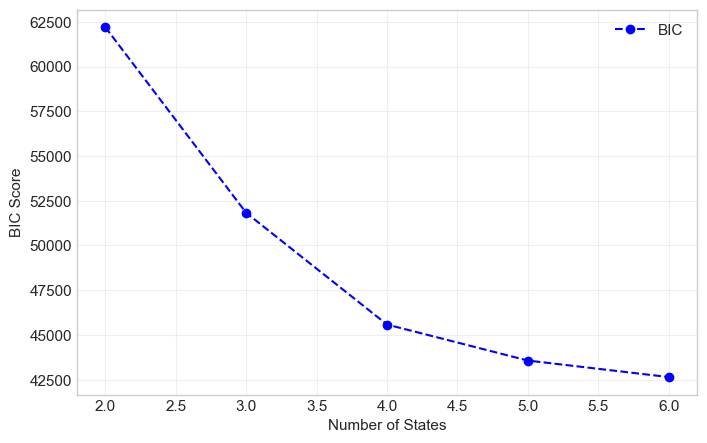

 6 States


In [12]:
# HMM state count, BIC over 2–6 states

print("Running HMM State Selection Audit (2 to 5 states)...")
print("(This uses the BIC Score: Lower is Better)")

# Prepare Data 
# We use a random sample of 20,000 points to keep it fast
X_audit = X_train_scaled

# subsample for speed
if len(X_audit) > 20000:
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X_audit), 20000, replace=False)
    X_audit_sample = X_audit[idx]
else:
    X_audit_sample = X_audit

n_states_list = [2, 3, 4, 5, 6]
bic_scores = []
aic_scores = []

for n in n_states_list:
    model_test = GaussianHMM(n_components=n, covariance_type="full", n_iter=100, random_state=42)
    model_test.fit(X_audit_sample)
    
    log_likelihood = model_test.score(X_audit_sample)
    
    # Free parameters approximation for full-cov Gaussian HMM
    n_features = X_audit_sample.shape[1]
    d = n_features
    n_params = (n - 1) + (n * (n - 1)) + (n * d) + (n * (d * (d + 1) // 2))
    
    # BIC = -2 * LL + p * log(N)
    bic = -2 * log_likelihood + n_params * np.log(len(X_audit_sample))
    bic_scores.append(bic)
    
    print(f" States={n} | BIC={bic:,.0f} | LogLik={log_likelihood:,.0f}")

# Plot Results
plt.figure(figsize=(8, 5))
plt.plot(n_states_list, bic_scores, marker='o', linestyle='--', color='blue', label='BIC')
plt.xlabel("Number of States")
plt.ylabel("BIC Score")
plt.grid(True, alpha=0.3)
plt.legend()

save_figure("fig_5_7_bic")
bic_df = pd.DataFrame({"n_states": n_states_list, "bic": bic_scores})
save_table(bic_df, "tab_A_bic_scores", index=False)

plt.show()

# Recommendation
best_n = n_states_list[np.argmin(bic_scores)]
print(f" {best_n} States")

## 10. Per-event Viterbi - non-causal labels

This computes the most likely state path for each event with the Viterbi algorithm, one event at a time so there is no bleeding across events. Viterbi is non-causal: it uses the whole event to label each minute. These labels are therefore used only for interpretation (the regime figures and the regime-definition table) and for the oracle upper bound later, never for the causal forecasting result, which uses the filtered states from the next cell.

In [13]:
# 2.2 Per-event Viterbi states

viterbi_states = np.full(len(X_robust), fill_value=-1, dtype=int)
X_robust = X_robust.sort_values(["event_id", "ts_utc"]).reset_index(drop=True)
X_scaled_robust = X_scaled_robust[X_robust.index] 

assert len(X_scaled_robust) == len(X_robust), "Scaled matrix and dataframe misaligned!"

# Iterate over event slices using indices
for eid, idx in X_robust.groupby("event_id", sort=False).indices.items():
    idx = np.asarray(idx)
    X_evt = X_scaled_robust[idx]  # already scaled

    # One sequence per event
    st = model_robust.predict(X_evt)
    viterbi_states[idx] = st

X_robust["state_viterbi_evt"] = viterbi_states

# Sanity check
assert (X_robust["state_viterbi_evt"] >= 0).all(), "Some rows did not get a Viterbi state!"
print("Per-event Viterbi states computed. Unique states:", np.unique(viterbi_states))


Per-event Viterbi states computed. Unique states: [0 1 2]


## 11. Causal forward filter

This cell produces the causal regime labels. For each event it runs the HMM forward algorithm in log space, computing at every minute the filtered state distribution given only the observations up to and including that minute, with no backward or smoothing pass. Each event is ordered from far to near kick-off, the Gaussian log-emission probabilities are built, and the filtered distribution is propagated forward and normalised at each step with logsumexp for numerical stability. The most likely state from this filtered distribution is the causal state at each minute. Because it uses only information available at the time, these labels can be fed into a one-step-ahead filter without look-ahead, which is the key difference from the non-causal Viterbi path above.

In [14]:
# 2.4 Causal filtered probabilities per event (forward algorithm)

assert len(X_scaled_robust) == len(X_robust), "X_scaled_robust and X_robust are misaligned!"
assert "tau_min" in X_robust.columns, "Need tau_min to enforce within-event chronological order."

K = model_robust.n_components
d = X_scaled_robust.shape[1]

A = model_robust.transmat_
logA = np.log(A + 1e-300)  # to avoid log(0)

logpi = np.log(model_robust.startprob_ + 1e-300)

means = model_robust.means_
covars = model_robust.covars_

# Precompute per-state inverse cov and log-determinant
inv_cov = []
log_det = []
for k in range(K):
    C = covars[k]
    invC = np.linalg.inv(C)
    sign, ld = np.linalg.slogdet(C)
    if sign <= 0:
        raise ValueError(f"Covariance matrix for state {k} is not PD (sign={sign}).")
    inv_cov.append(invC)
    log_det.append(ld)
inv_cov = np.stack(inv_cov, axis=0)
log_det = np.array(log_det)

const = -0.5 * (d * np.log(2 * np.pi))

def log_emission_probs(X_evt):
    """
    Returns log B[t,k] = log p(x_t | state=k)
    X_evt: (T,d) in scaled space
    """
    T = X_evt.shape[0]
    out = np.empty((T, K), dtype=float)
    for k in range(K):
        diff = X_evt - means[k]
        quad = np.einsum("ij,jk,ik->i", diff, inv_cov[k], diff)  # (T,)
        out[:, k] = const - 0.5 * (log_det[k] + quad)
    return out

# Allocate outputs
filt_probs = np.full((len(X_robust), K), np.nan, dtype=float)
causal_state = np.full(len(X_robust), -1, dtype=int)

bad_tau = 0

for eid, idx in X_robust.groupby("event_id", sort=False).indices.items():
    idx = np.asarray(idx)

    # Chronological order within event: far -> near kickoff
    idx_sorted = (
        X_robust.loc[idx]
        .sort_values("tau_min", ascending=False)
        .index.to_numpy()
    )

    if not X_robust.loc[idx_sorted, "tau_min"].is_monotonic_decreasing:
        bad_tau += 1

    X_evt = X_scaled_robust[idx_sorted]
    T = X_evt.shape[0]

    logB = log_emission_probs(X_evt)  # (T,K)
    log_alpha = np.empty((T, K), dtype=float)

    # t=0
    log_alpha[0] = logpi + logB[0]
    log_alpha[0] -= logsumexp(log_alpha[0])

    # t=1..T-1
    for t in range(1, T):
        log_alpha_pred = logsumexp(log_alpha[t-1][:, None] + logA, axis=0)
        log_alpha[t] = log_alpha_pred + logB[t]
        log_alpha[t] -= logsumexp(log_alpha[t])

    probs = np.exp(log_alpha)

    # write back using idx_sorted 
    filt_probs[idx_sorted] = probs
    causal_state[idx_sorted] = np.argmax(probs, axis=1)

print("Events with non-monotonic tau_min after sorting (should be 0):", bad_tau)


# Attach to df
for k in range(K):
    X_robust[f"p_filt_{k}"] = filt_probs[:, k]
X_robust["causal_state"] = causal_state

assert np.isfinite(filt_probs).all(), "Non-finite filtered probabilities found!"
assert (X_robust["causal_state"] >= 0).all(), "Some rows did not get a causal state!"
print("Causal filtered state probabilities computed.")


Events with non-monotonic tau_min after sorting (should be 0): 0
Causal filtered state probabilities computed.


## 12. Regime labelling and figures

This cell fixes the regime naming by volatility (lowest-volatility state to Static_Illiquid, highest to Volatile_Shock, the remainder to Normal_Trading) and produces three figures: regime occupancy over tau (how the probability of each regime evolves toward kick-off, with Static_Illiquid declining and Normal_Trading rising), feature distributions by regime, and the transition-probability matrix. In the feature distributions, Static_Illiquid sits at essentially zero volatility, which follows from the wide-spread zero-return rule described above.

 State feature means (inverse-scaled)
   log_vol  spread_rel  log_tick_count  vol_real
0   0.9937      0.0240          3.8898    1.7011
1   2.1151      0.0641          3.8542    7.2908
2   0.0000      0.0654          3.4594    0.0000

--- FINAL MAPPING ---
State 2 -> Static_Illiquid (Vol: 0.0000%)
State 0 -> Normal_Trading  (Vol: 1.7011%)
State 1  -> Volatile_Shock  (Vol: 7.2908%)
Saved: fig_5_8_regime_occupancy.png, fig_5_8_regime_occupancy.pdf


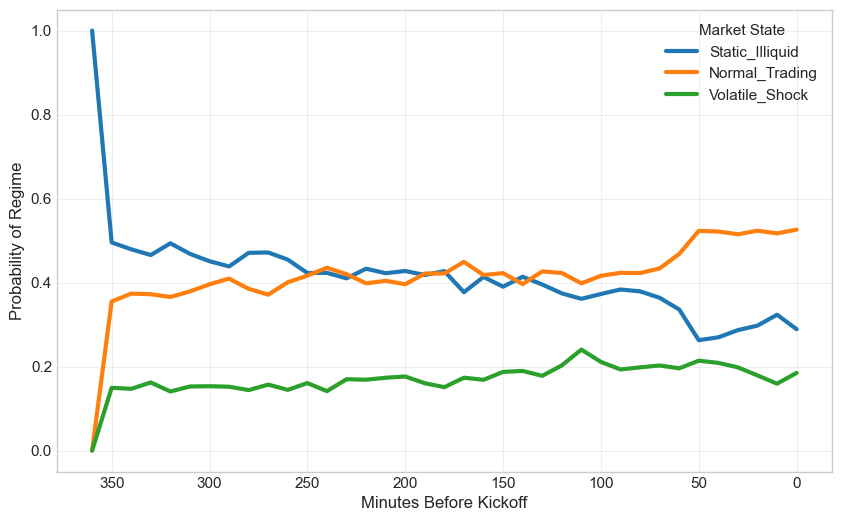

Saved: fig_A_feature_distributions.png, fig_A_feature_distributions.pdf


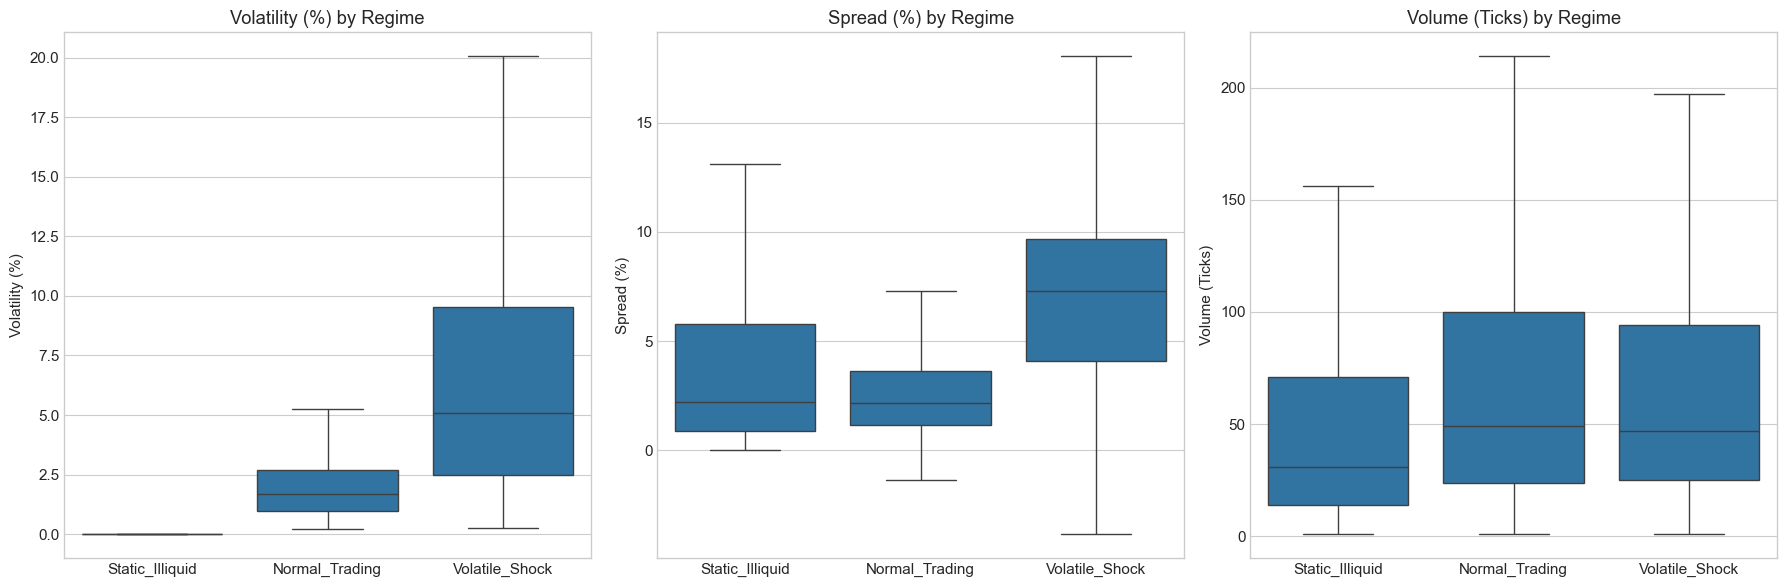

Saved: fig_A_transition_matrix.png, fig_A_transition_matrix.pdf


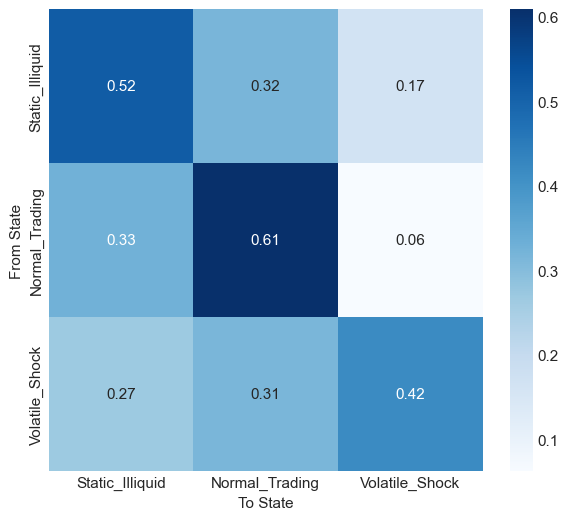

In [15]:
# 3. Visualisation and Analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Recompute state means in original feature units for interpretation
means_trans = scaler_robust.inverse_transform(model_robust.means_)
df_means = pd.DataFrame(means_trans, columns=["log_vol", "spread_rel", "log_tick_count"])
df_means["vol_real"] = np.expm1(df_means["log_vol"])

print(" State feature means (inverse-scaled)")
print(df_means)

# Identify states by volatility level
static_id = df_means["vol_real"].idxmin()

shock_id = df_means["vol_real"].idxmax()

all_ids = set(df_means.index)
normal_id = list(all_ids - {static_id, shock_id})[0]

state_label_map = {
    static_id: "Static_Illiquid",
    normal_id: "Normal_Trading",
    shock_id:  "Volatile_Shock"
}

# Canonical Integer Map (0=Static, 1=Normal, 2=Shock)
canon_map = {
    static_id: 0,
    normal_id: 1,
    shock_id:  2
}

order = ["Static_Illiquid", "Normal_Trading", "Volatile_Shock"]

# Map to labels
X_robust["state_name"] = X_robust["state_viterbi_evt"].map(state_label_map)

print("\n--- FINAL MAPPING ---")
print(f"State {static_id} -> Static_Illiquid (Vol: {df_means.loc[static_id, 'vol_real']:.4f}%)")
print(f"State {normal_id} -> Normal_Trading  (Vol: {df_means.loc[normal_id, 'vol_real']:.4f}%)")
print(f"State {shock_id}  -> Volatile_Shock  (Vol: {df_means.loc[shock_id, 'vol_real']:.4f}%)")

# Figure 1: Regime occupancy over tau (10-min bins)
X_robust['tau_bin'] = (X_robust['tau_min'] // 10) * 10

# Calculate occupancy
occupancy = X_robust.groupby(['tau_bin', 'state_name']).size().unstack(fill_value=0)
occupancy_pct = occupancy.div(occupancy.sum(axis=1), axis=0)

plt.figure(figsize=(10, 6))
for label in order:
    if label in occupancy_pct.columns:
        plt.plot(occupancy_pct.index, occupancy_pct[label], 
                 label=label, linewidth=3)

plt.gca().invert_xaxis() 
plt.xlabel("Minutes Before Kickoff", fontsize=12)
plt.ylabel("Probability of Regime", fontsize=12)
plt.legend(title='Market State')
plt.grid(True, alpha=0.3)
save_figure("fig_5_8_regime_occupancy")
plt.show()

# Figure 2: Feature distribution by regime
plot_data = X_robust.copy()
plot_data['Volatility (%)'] = np.expm1(plot_data['log_vol'])
plot_data['Spread (%)'] = plot_data['spread_rel'] * 100
plot_data['Volume (Ticks)'] = np.expm1(plot_data['log_tick_count'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['Volatility (%)', 'Spread (%)', 'Volume (Ticks)']

for i, metric in enumerate(metrics):
    sns.boxplot(x='state_name', y=metric, data=plot_data, 
                order=order, ax=axes[i], showfliers=False)
    axes[i].set_title(f"{metric} by Regime")
    axes[i].set_xlabel("")

plt.tight_layout()
save_figure("fig_A_feature_distributions")
plt.show()

# Figure 3: Transition matrix (re-ordered to match labels
indices = [static_id, normal_id, shock_id]
ordered_trans_mat = model_robust.transmat_[np.ix_(indices, indices)]

plt.figure(figsize=(7, 6))
sns.heatmap(ordered_trans_mat, annot=True, fmt=".2f", cmap="Blues", 
            xticklabels=order, yticklabels=order)
plt.ylabel("From State")
plt.xlabel("To State")
save_figure("fig_A_transition_matrix")
plt.show()

## 13. Regime diagnostics

Supporting checks on the fitted regimes: the transition matrix printed in label order, the implied expected duration of each regime (one over one minus the self-transition probability, which comes out to roughly two minutes, so the regimes are high-frequency states rather than long phases), a count of near-dead minutes (zero to one ticks) and confirmation they map to Static_Illiquid, the share of rows hitting the 0.50 spread cap, and a per-state spread summary. It finishes with a labelled sample-event figure (price, spread with the clip line, and the coloured regime strip) so the regime assignment can be checked on a single match.


 Transition probabilities (ordered Static -> Normal -> Shock):
Static_Illiquid : 0.5165 0.3181 0.1654
Normal_Trading  : 0.3288 0.6089 0.0623
Volatile_Shock  : 0.2678 0.3145 0.4177

 Implied expected duration (1 / (1 - Self_Transition_Prob))
Static_Illiquid   : 2.1 minutes
Normal_Trading    : 2.6 minutes
Volatile_Shock    : 1.7 minutes


Total 'Dead' Minutes (0-1 ticks): 339 out of 102785
state_label_viterbi
Static_Illiquid   0.7640
Normal_Trading    0.1652
Volatile_Shock    0.0708
Name: proportion, dtype: float64

Rows at/above spread cap (0.50): 3054 (2.97%)

Spread summary by state (mean/min/max):
                      mean     min    max
state_label_viterbi                      
Normal_Trading      0.0252 -0.0139 0.0769
Static_Illiquid     0.0733  0.0000 0.5000
Volatile_Shock      0.0730 -0.0385 0.2000
Saved: fig_hmm_sample_event_27468364.png, fig_hmm_sample_event_27468364.pdf


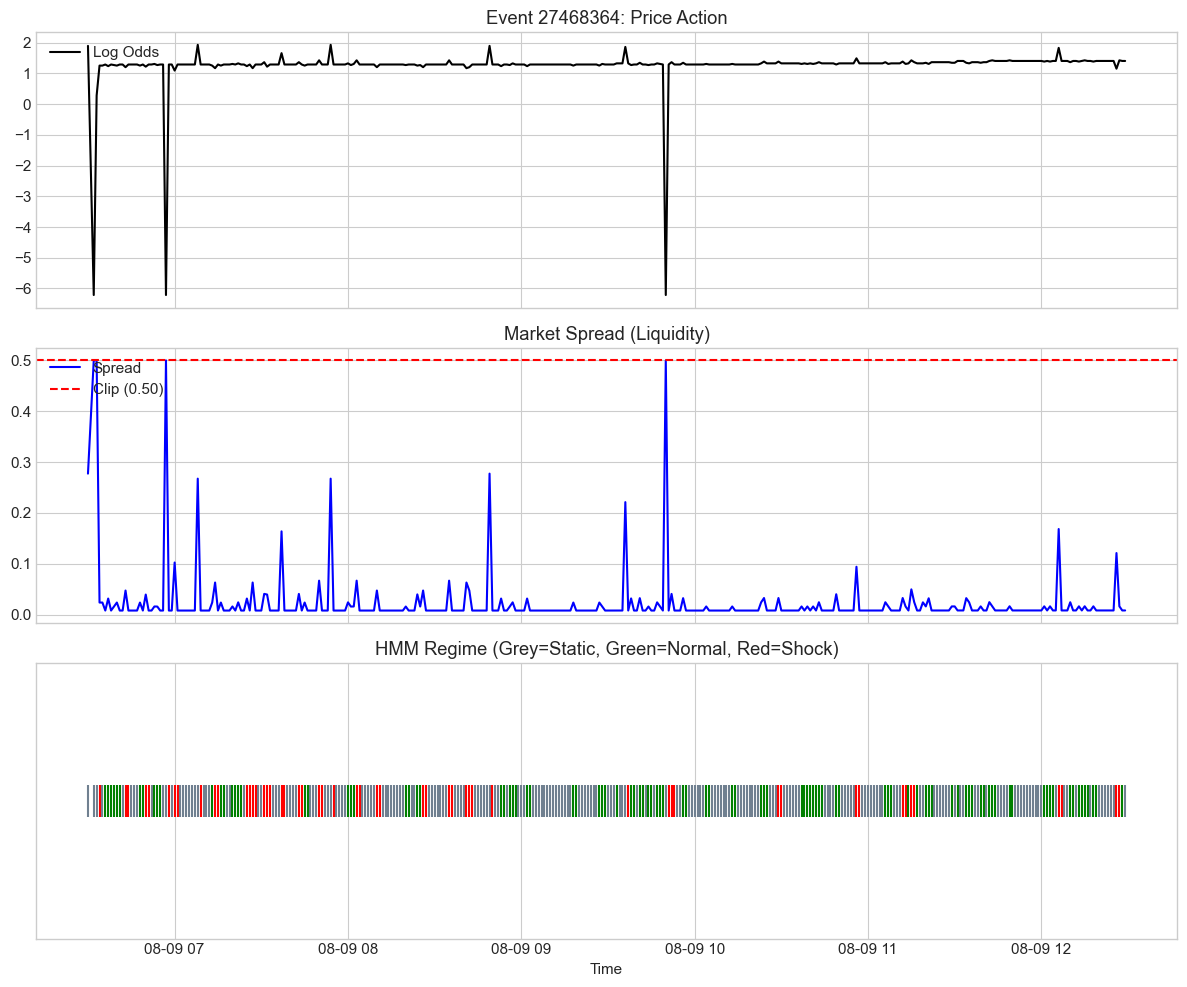

In [ ]:
# Diagnostics (HMM regimes)

# Required inputs
if 'state_viterbi_evt' not in X_robust.columns:
   raise KeyError("state_viterbi_evt missing. Run the per-event Viterbi cell first.")

# State label lookup (from previous mapping cell)
diag_order = [static_id, normal_id, shock_id]
diag_labels = {
    static_id: "Static_Illiquid",
    normal_id: "Normal_Trading",
    shock_id:  "Volatile_Shock"
}

X_robust["state_label_viterbi"] = X_robust["state_viterbi_evt"].map(diag_labels)


# Transition matrix + implied expected duration

trans_mat = model_robust.transmat_

print("\n Transition probabilities (ordered Static -> Normal -> Shock):")

for i in diag_order:
    row = " ".join([f"{trans_mat[i, j]:.4f}" for j in diag_order])
    print(f"{diag_labels[i]:<16}: {row}")

print("\n Implied expected duration (1 / (1 - Self_Transition_Prob))")
for i in diag_order:
    p_ii = trans_mat[i, i]
    # Cap duration at 999 to avoid inf
    duration = 1.0 / (1.0 - p_ii) if p_ii < 0.9999 else 999.0
    print(f"{diag_labels[i]:<18}: {duration:.1f} minutes")


# Staleness check (0-1 ticks) should be classified as "Static_Illiquid"
stale_data = X_robust[X_robust['tick_count'] <= 1]
print(f"Total 'Dead' Minutes (0-1 ticks): {len(stale_data)} out of {len(X_robust)}")

stale_counts = stale_data['state_label_viterbi'].value_counts(normalize=True)
print(stale_counts)


# Spread clip impact

n_clipped = (X_robust["spread_rel"] >= 0.50).sum()
pct_clipped = 100 * n_clipped / len(X_robust)
print(f"\nRows at/above spread cap (0.50): {n_clipped} ({pct_clipped:.2f}%)")

print("\nSpread summary by state (mean/min/max):")
print(
    X_robust.groupby("state_label_viterbi")["spread_rel"]
    .describe()[["mean", "min", "max"]]
)

# Verification on a single event that hits the 'shock' state

shock_events = X_robust[X_robust['state_viterbi_evt'] == shock_id]['event_id'].unique()

if len(shock_events) > 0:
    sample_id = shock_events[0] 
    sample_data = X_robust[X_robust['event_id'] == sample_id].copy()

    # Setup Colors: Static=Grey, Normal=Green, Shock=Red
    cmap = {static_id: 'slategrey', normal_id: 'green', shock_id: 'red'}
    
    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # Plot A: Price
    axes[0].plot(sample_data['ts_utc'], sample_data['log_odds'], color='black', label='Log Odds')
    axes[0].set_title(f"Event {sample_id}: Price Action")
    axes[0].legend(loc='upper left')

    # Plot B: Spread
    axes[1].plot(sample_data['ts_utc'], sample_data['spread_rel'], color='blue', label='Spread')
    axes[1].axhline(0.50, color='red', linestyle='--', label='Clip (0.50)')
    axes[1].set_title("Market Spread (Liquidity)")
    axes[1].legend(loc='upper left')

    # Plot C: Regime Strip
    colors = [cmap[s] for s in sample_data['state_viterbi_evt']]
    axes[2].scatter(sample_data['ts_utc'], [1]*len(sample_data), c=colors, marker='|', s=500)
    axes[2].set_yticks([])
    axes[2].set_title("HMM Regime (Grey=Static, Green=Normal, Red=Shock)")
    axes[2].set_xlabel("Time")

    plt.tight_layout()
    save_figure(f"fig_hmm_sample_event_{sample_id}", fig)
    plt.show()
else:
    print("No events found with 'Volatile_Shock' state to plot.")

## 14. Time steps and the regime series

This prepares the inputs the Kalman filter needs. The time step dt is the actual minutes between consecutive observations within each event, so the filter's transition and process noise scale with real elapsed time rather than row index. It then builds two regime series: the nowcast series is the causal filtered state at time t, and the strict series is the causal state lagged one step (the regime known strictly before t), initialised to Normal_Trading for the first minute. The headline result uses the strict series as the most conservative causal choice; the nowcast series is reported only as a sensitivity.

In [17]:
# Utility function
def sigmoid(x):
    x = np.clip(x, -20, 20)
    return 1.0 / (1.0 + np.exp(-x))

# Calculate time delta
print("Calculating Time Deltas (dt)...")

assert "tau_min" in X_robust.columns
assert "causal_state" in X_robust.columns, "Run the causal filtering cell first!"
assert "normal_id" in locals(), "normal_id not found. Run the state labelling block first."

K = model_robust.n_components
assert 0 <= int(normal_id) < K, f"normal_id={normal_id} is not a valid HMM state index (K={K})."

X_robust["dt"] = np.nan

for eid, g in X_robust.groupby("event_id"):
    gg = g.sort_values("tau_min", ascending=False) # far -> near kickoff
    tau = gg["tau_min"].to_numpy(dtype=float)

    dt = np.empty_like(tau)
    dt[0] = 1.0  # Default for first observation
    dt[1:] = tau[:-1] - tau[1:] # Difference between t-1 and t

    X_robust.loc[gg.index, "dt"] = dt

# Enforce a small positive minimum to avoid zeros/negatives from any irregularities
X_robust["dt"] = X_robust["dt"].clip(lower=1/60.0)

print("dt summary (minutes):")
print(X_robust["dt"].describe(percentiles=[0.5, 0.9, 0.99]).to_string())

# Regime series - Nowcast vs Strict
# Nowcast: Uses state at time t
# Strict:  Uses state at time t-1 

X_robust["state_nowcast"] = X_robust["causal_state"].astype(int)
X_robust["state_strict"] = np.nan

print(f"\nInitializing Strict Series with Normal State ID: {normal_id}")

for eid, g in X_robust.groupby("event_id"):
    gg = g.sort_values("tau_min", ascending=False)
    s = gg["state_nowcast"].to_numpy(dtype=int)

    s_strict = np.empty_like(s)
    
    # Initialize with 'Normal_Trading', not 'Static'
    s_strict[0] = normal_id 
    
    # State at t is now shifted to State at t-1
    s_strict[1:] = s[:-1]

    X_robust.loc[gg.index, "state_strict"] = s_strict

X_robust["state_strict"] = X_robust["state_strict"].astype(int)

# Backwards-compatibility alias
X_robust["state_kf"] = X_robust["state_strict"]

# Verify
first_rows = X_robust.loc[X_robust.groupby("event_id")["tau_min"].idxmax()]
print(f"\nFirst-row initialization check (Target: {normal_id}):")
print(first_rows["state_strict"].value_counts())

assert (first_rows["state_strict"] == normal_id).all(), "First rows not initialized to Normal state!"
print("\nBlock complete: dt and regime series created.")

Calculating Time Deltas (dt)...
dt summary (minutes):
count   102785.0000
mean         1.0132
std          0.7454
min          1.0000
50%          1.0000
90%          1.0000
99%          1.0000
max         94.0000

Initializing Strict Series with Normal State ID: 0

First-row initialization check (Target: 0):
state_strict
0    290
Name: count, dtype: int64

Block complete: dt and regime series created.


## 15. The switching Kalman filter and the static baseline

The switching filter is a local-level-plus-trend Kalman filter: the latent state is level and trend, it observes the level (the log-odds price), and its process noise and measurement noise switch with the supplied regime at each step, both scaled by dt. This is the regime-adaptive mechanism: in calmer regimes the filter trusts its model more, and in shock regimes it can down-weight observations or allow faster adjustment.

The static baseline uses a single noise pair for all regimes. Rather than fixing these values, they are grid-searched on the validation set and the lowest-RMSE pair is kept.. This gives the switching model a fair, data-chosen baseline to beat.

In [18]:
import numpy as np
from scipy.optimize import minimize

# Kalman filter class
class DynamicSwitchingKF:
    """
    Local level + trend Kalman filter where measurement/process noise parameters
    switch by externally supplied regime (e.g., HMM state per time step).
    """
    def __init__(self, regime_params):
        self.regime_params = regime_params
        self.H = np.array([[1.0, 0.0]])  # observe level only
        self.x = np.zeros(2)             # [level, trend]
        self.P = np.eye(2) * 1.0

    def initialize(self, first_obs):
        self.x = np.array([float(first_obs), 0.0])
        self.P = np.eye(2) * 1.0

    def step(self, z, state, dt):
        """
        One Kalman filter step with regime-dependent noise.

        Returns:
            pred_level: predicted level x_{t|t-1}[0]
            innov:      innovation (z - y_hat)
            S:          innovation variance
            z_std:      standardized innovation
        """
        params = self.regime_params[int(state)]
        R = float(params["R"])
        dt = float(dt)

        # Transition (Local Level + Trend)
        F = np.array([[1.0, dt],
                      [0.0, 1.0]])

        # Process Noise (Scales with dt)
        Q = np.array([[float(params["Q_l"]) * dt, 0.0],
                      [0.0, float(params["Q_s"]) * dt]])

        # Predict (A Priori)
        x_pred = F @ self.x
        P_pred = F @ self.P @ F.T + Q

        # Compare 
        y_hat = float((self.H @ x_pred).squeeze())
        innov = float(z) - y_hat
        S = float((self.H @ P_pred @ self.H.T).squeeze() + R)
        S = max(S, 1e-9)
        
        # Avoid div by zero in standardization
        z_std = innov / np.sqrt(S) if S > 1e-9 else 0.0

        # Update
        K = (P_pred @ self.H.T) / S 
        self.x = x_pred + (K.flatten() * innov)
        self.P = (np.eye(2) - K @ self.H) @ P_pred

        return float(x_pred[0]), innov, S, z_std

# Static baseline Kalman filter parameters

# The static baseline is used as a reference model only.
# Unconstrained optimisation was found to be unstable and prone to degeneracy
# (Q -> 0, R -> very large). We therefore fix parameters to plausible values
# and focus inference on the regime-switching model.

# best_R = 0.3 ** 2    # measurement noise variance (log-odds scale)
# best_Q = 1e-4        # small but non-zero state drift

# Static baseline Kalman parameters - tuned on the validation set.
# We grid-search a single (Q, R) applied uniformly to every regime and keep the pair with the
# lowest validation RMSE. 
# The regime multipliers are then searched on top of this.
from collections import defaultdict

def _static_rmse(Q, R, ids):
    sse, n = 0.0, 0
    params = defaultdict(lambda: {"R": R, "Q_l": Q, "Q_s": Q})
    for eid in ids:
        d = X_robust[X_robust["event_id"] == eid]
        if "tau_min" in d.columns:
            d = d.sort_values("tau_min", ascending=False)
        if len(d) < 30:
            continue
        kf = DynamicSwitchingKF(params)
        kf.initialize(d["log_odds"].iloc[0])
        for t in range(1, len(d)):
            pred, *_ = kf.step(d["log_odds"].iloc[t],
                               d["state_kf"].iloc[t], d["dt"].iloc[t])
            err = sigmoid(d["log_odds"].iloc[t]) - sigmoid(pred)
            sse += err ** 2
            n += 1
    return np.sqrt(sse / n) if n else np.nan

Q_grid = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
R_grid = [0.005, 0.01, 0.02, 0.05, 0.09, 0.15]

_best = None
for _Q in Q_grid:
    for _R in R_grid:
        _r = _static_rmse(_Q, _R, val_ids)
        if _best is None or _r < _best[2]:
            _best = (_Q, _R, _r)

best_Q, best_R, _best_rmse = _best
print(f"Tuned baseline on validation: Q={best_Q}, R={best_R}, val RMSE={_best_rmse:.5f}")
print(f"Using fixed baseline parameters: R={best_R:.6f}, Q={best_Q:.6f}")

Tuned baseline on validation: Q=1e-05, R=0.15, val RMSE=0.05627
Using fixed baseline parameters: R=0.150000, Q=0.000010


## 16. Tuning the regime multipliers on validation

This defines the naive martingale benchmark (predict the next probability as the current one) and then grid-searches the regime multipliers on the validation set: how much to inflate the Normal regime's process noise (more active price discovery) and the Shock regime's measurement noise (down-weight dislocated quotes). The pair with the lowest validation RMSE is selected, using the strict causal regime series and only validation events, so the test set plays no part in tuning. The cell ends with a chronology check confirming train kicks off before test.

In [19]:

# Baselines and Kalman Filter validation
# This block compares a naive martingale benchmark against
# a regime-switching Kalman filter using a validation set.

# Naive Martingale benchmark in probability space

def evaluate_naive_benchmark(df_dataset, event_ids):
    """
    Calculates the RMSE of a Naive Martingale Predictor (P_t = P_{t-1}).
    Evaluated in Probability Space.
    """
    sse_naive = 0
    count = 0
    
    for eid in event_ids:
        df_evt = df_dataset[df_dataset['event_id'] == eid]
        if len(df_evt) < 30: continue
            
        obs_log = df_evt['log_odds'].values
        prob_true = sigmoid(obs_log)
        
        # Prediction for t is simply Observation at t-1
        prob_pred_naive = np.roll(prob_true, 1)
        
        # Calculate Error from t=1 onwards
        errors = (prob_true[1:] - prob_pred_naive[1:])**2
        sse_naive += np.sum(errors)
        count += len(errors)
        
    return np.sqrt(sse_naive / count)

# KF tuning on validation set

# Validation event IDs, constructed in split block
validation_ids = val_ids 

# Check that regime IDs from the HMM labelling step are available

if 'static_id' not in globals() or 'shock_id' not in globals():
    raise ValueError("State IDs are missing! Please run the 'UNIFIED DYNAMIC STATE LABELING' block first.")

print("Using scientifically defined State IDs:")
print(" static_id (Static/Illiquid) :", static_id)
print(" normal_id (Normal/Liquid)   :", normal_id)
print(" shock_id  (Volatile/Shock)  :", shock_id)

# Grid search over regime-specific noise multipliers
# Comparison against the naive benchmark.

q_mults = [0.1, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0, 50.0, 100.0, 500.0]
r_mults = [0.1, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0, 20.0]

results = []
print(f"\nTuning on {len(validation_ids)} validation events...")

# Per-event data ordered by time-to-kickoff
# and local time step (dt) derived from tau_min
def _event_panel_for_kf(df_evt):
    df_evt = df_evt.sort_values("tau_min", ascending=False).copy()

    tau = df_evt["tau_min"].values.astype(float)
    dt = np.empty_like(tau)
    dt[0] = 1.0
    dt[1:] = tau[:-1] - tau[1:]
    dt = np.clip(dt, 1/60.0, None)

    return df_evt, dt

for q_m in q_mults:
    for r_m in r_mults:

        # Build regime-dependent Kalman filter parameters
        # Regimes are supplied externally by the HMM
        switch_regimes = {
            0: {"R": best_R, "Q_l": best_Q, "Q_s": best_Q/10.0},
            1: {"R": best_R, "Q_l": best_Q, "Q_s": best_Q/10.0},
            2: {"R": best_R, "Q_l": best_Q, "Q_s": best_Q/10.0},
        }

        # Static - baseline dynamics (little price adjustment)
        # Normal - higher process noise (active price discovery)
        switch_regimes[normal_id]["Q_l"] *= q_m
        switch_regimes[normal_id]["Q_s"] *= q_m
        
        # Shock higher measurement noise (temporary dislocation)
        switch_regimes[shock_id]["R"]    *= r_m

        # Validation RMSE using strict (causal) regime switching
        sse = 0.0
        n = 0

        for eid in validation_ids:
            df_evt = X_robust[X_robust["event_id"] == eid]
            if len(df_evt) < 30: continue

            df_evt, dts = _event_panel_for_kf(df_evt)

            obs_log = df_evt["log_odds"].values.astype(float)
            prob_true = sigmoid(obs_log)
            states_kf = df_evt["state_kf"].values.astype(int)

            kf = DynamicSwitchingKF(switch_regimes)
            kf.initialize(obs_log[0])

            # one-step-ahead prediction
            for t in range(1, len(obs_log)):
                pred_log, _, _, _ = kf.step(obs_log[t], states_kf[t], dts[t])
                err = prob_true[t] - sigmoid(pred_log)
                sse += float(err * err)
                n += 1

        rmse = np.sqrt(sse / n) if n > 0 else np.nan
        results.append((q_m, r_m, rmse))
        print(f"Qx{q_m:<4} Rx{r_m:<3} -> val RMSE: {rmse:.5f}")

# Best-performing configuration on the validation set
best_q_mult, best_r_mult, best_val_rmse = sorted(results, key=lambda x: x[2])[0]
print(f" best_q_mult = {best_q_mult}")
print(f" best_r_mult = {best_r_mult}")
print(f" best_val_rmse = {best_val_rmse:.5f}")

# Ordering and split sanity checks

# Kickoff per event
event_kick = (
    df[["event_id", "market_time"]]
    .dropna(subset=["event_id", "market_time"])
    .groupby("event_id")["market_time"]
    .min()
)

def order_by_kickoff(ids):
    ids_list = list(ids)
    return sorted(ids_list, key=lambda eid: event_kick.loc[eid])

# Build ordered lists
train_ids_ord = order_by_kickoff(train_ids)
val_ids_ord   = order_by_kickoff(val_ids)
test_ids_ord  = order_by_kickoff(test_ids)

# Oordered list
val_set = set(val_ids_ord)
train_core_ids_ord = [eid for eid in train_ids_ord if eid not in val_set]

# Canonical aliases
validation_ids = val_ids_ord

print("Counts:")
print(f" Train: {len(train_ids_ord)} (Core: {len(train_core_ids_ord)} + Val: {len(val_ids_ord)})")
print(f" Test : {len(test_ids_ord)}")

print("\nChronology check (train before test):")
print(" Train Max Kickoff:", event_kick.loc[train_ids_ord].max())
print(" Test Min Kickoff :", event_kick.loc[test_ids_ord].min())
assert event_kick.loc[train_ids_ord].max() <= event_kick.loc[test_ids_ord].min(), "Chronology Violated!"
print(" >> Chronology OK.")

Using scientifically defined State IDs:
 static_id (Static/Illiquid) : 2
 normal_id (Normal/Liquid)   : 0
 shock_id  (Volatile/Shock)  : 1

Tuning on 50 validation events...
Qx0.1  Rx0.1 -> val RMSE: 0.05312
Qx0.1  Rx0.5 -> val RMSE: 0.05104
Qx0.1  Rx1.0 -> val RMSE: 0.05109
Qx0.1  Rx1.5 -> val RMSE: 0.05135
Qx0.1  Rx2.0 -> val RMSE: 0.05158
Qx0.1  Rx5.0 -> val RMSE: 0.05232
Qx0.1  Rx10.0 -> val RMSE: 0.05274
Qx0.1  Rx20.0 -> val RMSE: 0.05300
Qx0.5  Rx0.1 -> val RMSE: 0.05341
Qx0.5  Rx0.5 -> val RMSE: 0.05143
Qx0.5  Rx1.0 -> val RMSE: 0.05151
Qx0.5  Rx1.5 -> val RMSE: 0.05178
Qx0.5  Rx2.0 -> val RMSE: 0.05202
Qx0.5  Rx5.0 -> val RMSE: 0.05279
Qx0.5  Rx10.0 -> val RMSE: 0.05322
Qx0.5  Rx20.0 -> val RMSE: 0.05349
Qx1.0  Rx0.1 -> val RMSE: 0.05367
Qx1.0  Rx0.5 -> val RMSE: 0.05181
Qx1.0  Rx1.0 -> val RMSE: 0.05192
Qx1.0  Rx1.5 -> val RMSE: 0.05220
Qx1.0  Rx2.0 -> val RMSE: 0.05245
Qx1.0  Rx5.0 -> val RMSE: 0.05325
Qx1.0  Rx10.0 -> val RMSE: 0.05368
Qx1.0  Rx20.0 -> val RMSE: 0.05396
Qx1.

## 17. Test-set evaluation

The single, final evaluation on the held-out test events. The filters are rebuilt identically to the validation grid and the walk-forward (with the shock-state process noise set to a tenth of the level noise, applied consistently throughout) so the same model is compared everywhere. Four models are scored in probability space: naive martingale, static KF, switching KF with the strict causal regimes (the headline), and switching KF with the nowcast regimes (a non-causal sensitivity). This produces the main RMSE table. The strict-causal switching filter beats both the naive and static baselines; the nowcast variant is a little better still, which quantifies what perfect contemporaneous regime knowledge would add.

In [20]:
# Build the same filters the grid and walk-forward use (Q_s = best_Q/10),
# so validation selection, the test table, and the walk-forward all
# evaluate one and the same filter.
base_static = {
    0: {"R": best_R, "Q_l": best_Q, "Q_s": best_Q / 10.0},
    1: {"R": best_R, "Q_l": best_Q, "Q_s": best_Q / 10.0},
    2: {"R": best_R, "Q_l": best_Q, "Q_s": best_Q / 10.0},
}
static_params = base_static

switch_params = {s: dict(base_static[s]) for s in range(3)}
switch_params[normal_id]["Q_l"] *= best_q_mult
switch_params[normal_id]["Q_s"] *= best_q_mult
switch_params[shock_id]["R"]    *= best_r_mult

def rmse_naive(df, event_ids):
    sse = 0.0
    n = 0

    for eid in event_ids:
        df_evt = df[df["event_id"] == eid]

        if "tau_min" in df_evt.columns:
            df_evt = df_evt.sort_values("tau_min", ascending=False)

        p = sigmoid(df_evt["log_odds"].values)
        if len(p) < 30:
            continue

        for t in range(1, len(p)):
            err = p[t] - p[t - 1]
            sse += err ** 2
            n += 1

    return np.sqrt(sse / n) if n > 0 else np.nan


def rmse_kf(df, event_ids, regime_params, state_col):
    sse = 0.0
    n = 0

    for eid in event_ids:
        df_evt = df[df["event_id"] == eid]

        # enforce within-event ordering
        if "tau_min" in df_evt.columns:
            df_evt = df_evt.sort_values("tau_min", ascending=False)

        if len(df_evt) < 30:
            continue

        kf = DynamicSwitchingKF(regime_params)
        kf.initialize(df_evt["log_odds"].iloc[0])

        for t in range(1, len(df_evt)):
            z = df_evt["log_odds"].iloc[t]
            state = df_evt[state_col].iloc[t]
            dt = df_evt["dt"].iloc[t]

            pred, innov, _, _ = kf.step(z, state, dt)

            # Convert to probability space
            p_true = sigmoid(z)
            p_pred = sigmoid(pred)
            err = p_true - p_pred

            sse += err ** 2
            n += 1

    return np.sqrt(sse / n) if n > 0 else np.nan


# Evaluate models on the test set

print("Evaluating models on the TEST set...\n")

rmse_naive_test         = rmse_naive(X_robust, test_ids_ord)
rmse_static_test        = rmse_kf(X_robust, test_ids_ord, static_params, "state_kf")
rmse_switch_strict_test = rmse_kf(X_robust, test_ids_ord, switch_params, "state_strict")
rmse_switch_nowcast_test = rmse_kf(X_robust, test_ids_ord, switch_params, "state_nowcast")

print("TEST SET RMSE (Probability Space)")
print("--------------------------------")
print(f"Naive martingale              : {rmse_naive_test:.5f}")
print(f"Static KF                     : {rmse_static_test:.5f}")
print(f"Switching KF (Strict, causal) : {rmse_switch_strict_test:.5f}")
print(f"Switching KF (Nowcast, non-causal sensitivity) : {rmse_switch_nowcast_test:.5f}")

# Test set RMSE table

df_kf_test = pd.DataFrame({
    "Model": [
        "Naive martingale",
        "Static KF",
        "Switching KF (Strict)",
        "Switching KF (Nowcast)",
    ],
    "RMSE (probability scale)": [
        rmse_naive_test,
        rmse_static_test,
        rmse_switch_strict_test,
        rmse_switch_nowcast_test,
    ],
})

save_table(df_kf_test, "tab_5_6_kf_rmse", index=False)
print(df_kf_test)

Evaluating models on the TEST set...

TEST SET RMSE (Probability Space)
--------------------------------
Naive martingale              : 0.06411
Static KF                     : 0.05880
Switching KF (Strict, causal) : 0.05792
Switching KF (Nowcast, non-causal sensitivity) : 0.05626
Saved: tab_5_6_kf_rmse.csv, tab_5_6_kf_rmse.tex
                    Model  RMSE (probability scale)
0        Naive martingale                    0.0641
1               Static KF                    0.0588
2   Switching KF (Strict)                    0.0579
3  Switching KF (Nowcast)                    0.0563


## 18. Oracle upper bound (non-causal)

A non-causal diagnostic. It reruns the multiplier grid but feeds the filter the ex-post Viterbi regime path, that is, regimes decided with knowledge of the whole event. This is not a deployable model and is never used for selection; it only measures the theoretical headroom if regimes were known in advance. The best oracle configuration improves on the static filter by about 11.7%. Set against the roughly 1.5% causal gain from the test set, this shows that most of the achievable improvement depends on knowing the regime non-causally, so the realistic deployable gain is modest and the gap is the cost of having to infer regimes in real time.

ORACLE sweep (Viterbi regimes; non-causal).
Running on 50 events (subset_n=50).
   > Calculating Static baseline (oracle subset)... RMSE: 0.05940
Saved: tab_A_oracle_grid.csv, tab_A_oracle_grid.tex
Saved: fig_A_oracle_heatmap.png, fig_A_oracle_heatmap.pdf


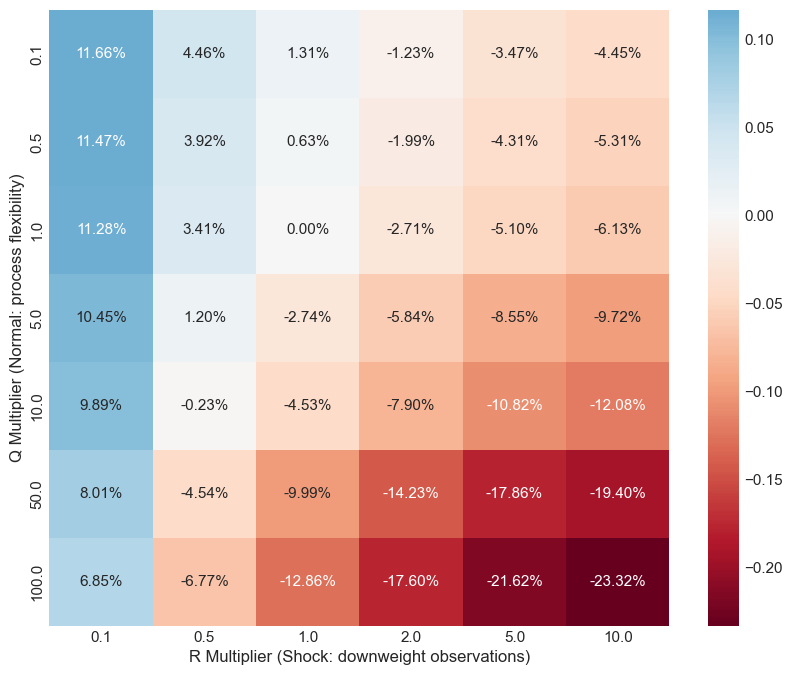


=== ORACLE BEST CONFIGURATION (UPPER BOUND) ===
Q Mult: 0.1x
R Mult: 0.1x
Improvement vs Static: 11.66%
Oracle headroom: some settings beat Static under ex-post regime assignment (non-causal).


In [21]:
# Oracle upper bound 
# - Diagnostic only, estimate theoretical headroom if regimes were known

print("ORACLE sweep (Viterbi regimes; non-causal).")

# fail-fast
try:
    _ = X_robust, sigmoid, DynamicSwitchingKF, best_R, best_Q, normal_id, shock_id, test_ids_ord
except NameError as e:
    raise NameError("Missing required objects. Run the earlier setup/model cells first.") from e

# Setup, run on vaidation
ids_for_oracle = list(test_ids_ord)

# Subset for runtime
subset_n = 50
oracle_subset = ids_for_oracle[:subset_n]
print(f"Running on {len(oracle_subset)} events (subset_n={subset_n}).")

# Grid of multipliers
q_grid = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
r_grid = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# Storage
results_grid = []

# Oracle Regimes
def run_kf_oracle(ids, regimes_dict):
    sse, n = 0.0, 0
    for eid in ids:
        df_evt = X_robust[X_robust["event_id"] == eid]
        if len(df_evt) < 30:
            continue

        # Ensure consistent event-time ordering (far -> near kickoff)
        df_evt = df_evt.sort_values("tau_min", ascending=False)

        obs = df_evt["log_odds"].values.astype(float)
        p_true = sigmoid(obs)

        # Oracle: ex-post Viterbi state path (non-causal)
        if "state_viterbi_evt" not in df_evt.columns:
            raise ValueError("state_viterbi_evt missing. Run per-event Viterbi block first.")
        states = df_evt["state_viterbi_evt"].values.astype(int)

        # dt from tau_min
        tau = df_evt["tau_min"].values.astype(float)
        dt = np.empty_like(tau)
        dt[0] = 1.0
        dt[1:] = tau[:-1] - tau[1:]
        dt = np.clip(dt, 1/60.0, None)

        # Filter
        kf = DynamicSwitchingKF(regimes_dict)
        kf.initialize(obs[0])

        for t in range(1, len(obs)):
            pred_log, _, _, _ = kf.step(obs[t], states[t], dt[t])
            err = p_true[t] - sigmoid(pred_log)
            sse += float(err * err)
            n += 1

    return np.sqrt(sse / n) if n > 0 else np.nan

# Baseline static on same subset
print("   > Calculating Static baseline (oracle subset)...", end="")
base_static_dict = {k: {'R': best_R, 'Q_l': best_Q, 'Q_s': best_Q/10.0} for k in range(3)}
rmse_static = run_kf_oracle(oracle_subset, base_static_dict)
print(f" RMSE: {rmse_static:.5f}")

# Grid sweep

for q_m in q_grid:
    for r_m in r_grid:
        # Copy baseline
        curr_regimes = {s: dict(base_static_dict[s]) for s in range(3)}

        # Normal, inflate process noise (more flexible latent evolution)
        curr_regimes[normal_id]['Q_l'] *= q_m
        curr_regimes[normal_id]['Q_s'] *= q_m

        # Shock, inflate measurement noise (downweight observations)
        curr_regimes[shock_id]['R'] *= r_m

        rmse_curr = run_kf_oracle(oracle_subset, curr_regimes)

        results_grid.append({
            "Q_Mult": q_m,
            "R_Mult": r_m,
            "RMSE": rmse_curr,
            "Improvement": (rmse_static - rmse_curr) / rmse_static
        })

# Heatmap Visualisation
df_grid = pd.DataFrame(results_grid)
pivot_table = df_grid.pivot(index="Q_Mult", columns="R_Mult", values="Improvement")
save_table(pivot_table, "tab_A_oracle_grid", index=True)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".2%", cmap="RdBu", center=0)
plt.xlabel("R Multiplier (Shock: downweight observations)", fontsize=12)
plt.ylabel("Q Multiplier (Normal: process flexibility)", fontsize=12)
save_figure("fig_A_oracle_heatmap")
plt.show()

# Best configuration upper bound
best_run = df_grid.loc[df_grid["Improvement"].idxmax()]
print("\n=== ORACLE BEST CONFIGURATION (UPPER BOUND) ===")
print(f"Q Mult: {best_run['Q_Mult']}x")
print(f"R Mult: {best_run['R_Mult']}x")
print(f"Improvement vs Static: {best_run['Improvement']:.2%}")

if best_run["Improvement"] > 0:
    print("Oracle headroom: some settings beat Static under ex-post regime assignment (non-causal).")
else:
    print("Oracle headroom: no setting beat Static even under ex-post regime assignment (non-causal).")


## 19. Walk-forward robustness

A robustness check rather than a tuning step. The events are processed in chronological order and split into five sequential folds, and in each fold the switching filter (with the validation-selected multipliers and strict regimes) is compared against the static baseline. The switching model wins in all five folds with a mean improvement of about 1.64%, close to the single test-set figure. This consistency across time is the main evidence that the small switching gain is stable rather than an artefact of one test split.

In [ ]:
# Robustness Check - Walk-Forward Validation

print("\nRunning Walk Forward Validation (5 folds)...")


# fail-fast

try:
    _ = (
        df, X_robust, sigmoid, DynamicSwitchingKF,
        train_core_ids_ord, val_ids_ord, test_ids_ord,
        best_R, best_Q, best_q_mult, best_r_mult,
        normal_id, shock_id,
        save_table
    )
except NameError as e:
    raise NameError(
        "Missing required objects. Run the earlier cells in order (data split, model fit, IDs ordering, helpers)."
    ) from e


# Use best multipliers explicitly
q_mult = best_q_mult
r_mult = best_r_mult

# Re-build sorted lists if they are missing or if only sets exist
def _get_sorted_ids(id_set):
    subset = df[df['event_id'].isin(id_set)]
    kickoffs = subset.groupby('event_id')['market_time'].min().sort_values()
    return kickoffs.index.tolist()

# rebuild if the ordered versions don't exist yet

train_ids_ord = _get_sorted_ids(train_ids)
val_ids_ord   = _get_sorted_ids(val_ids)
test_ids_ord  = _get_sorted_ids(test_ids)
        

val_set_check = set(val_ids_ord)
train_core_ids_ord = [eid for eid in train_ids_ord if eid not in val_set_check]

# Walk-forward setup
n_folds = 5
all_ids_sorted = train_core_ids_ord + val_ids_ord + test_ids_ord
total_events = len(all_ids_sorted)
fold_size = int(total_events / (n_folds + 1)) 

print(f"Total Events: {total_events} | Approx events per fold: {fold_size}")

# Define Models
base_static = {
    0: {'R': best_R, 'Q_l': best_Q, 'Q_s': best_Q/10.0},
    1: {'R': best_R, 'Q_l': best_Q, 'Q_s': best_Q/10.0},
    2: {'R': best_R, 'Q_l': best_Q, 'Q_s': best_Q/10.0}
}


base_switch = {s: dict(base_static[s]) for s in range(3)}

act_id = normal_id if 'normal_id' in globals() else 2
shk_id = shock_id if 'shock_id' in globals() else 0

base_switch[act_id]['Q_l'] *= q_mult
base_switch[act_id]['Q_s'] *= q_mult
base_switch[shk_id]['R']   *= r_mult

# Helper Function
def calc_rmse_fold(ids, regimes, mode="const"):
    sse, n = 0.0, 0
    for eid in ids:
        df_evt = X_robust[X_robust["event_id"] == eid]
        if len(df_evt) < 30: continue
        
        # Create panel
        df_evt = df_evt.sort_values("tau_min", ascending=False).copy()
        tau = df_evt["tau_min"].values.astype(float)
        dt = np.empty_like(tau)
        dt[0] = 1.0; dt[1:] = tau[:-1] - tau[1:]; dt = np.clip(dt, 1/60.0, None)
        
        obs = df_evt["log_odds"].values.astype(float)
        p_true = sigmoid(obs)
        
        if mode == "const": states = np.full(len(obs), act_id, dtype=int)
        else: states = df_evt[mode].values.astype(int)
            
        kf = DynamicSwitchingKF(regimes)
        kf.initialize(obs[0])
        for t in range(1, len(obs)):
            pred, _, _, _ = kf.step(obs[t], states[t], dt[t])
            err = p_true[t] - sigmoid(pred)
            sse += float(err*err)
            n += 1
    return np.sqrt(sse/n) if n > 0 else np.nan

# Run Loop
results_walk = []

for i in range(n_folds):
    start_idx = i * fold_size
    end_idx   = (i + 1) * fold_size
    fold_ids = all_ids_sorted[start_idx : end_idx]
    
    if len(fold_ids) == 0: break
    
    # Evaluate
    rmse_stat = calc_rmse_fold(fold_ids, base_static, "const")
    rmse_swit = calc_rmse_fold(fold_ids, base_switch, "state_kf")
    
    # Calc Improvement

    if np.isnan(rmse_stat) or np.isnan(rmse_swit):
        continue
        
    imp_pct = (rmse_stat - rmse_swit) / rmse_stat
    
    results_walk.append({
        "Fold": i+1,
        "Events": len(fold_ids),
        "Static_RMSE": rmse_stat,
        "Switch_RMSE": rmse_swit,
        "Improvement": imp_pct
    })
    
    print(f"Fold {i+1}: Events {len(fold_ids)} | Static {rmse_stat:.5f} vs Switch {rmse_swit:.5f} | Imp: {imp_pct:+.2%}")

# Summary and Save
df_res = pd.DataFrame(results_walk)
save_table(df_res, "tab_A_walkforward", index=False)
if not df_res.empty:
    wins = len(df_res[df_res["Improvement"] > 0])
    avg_imp = df_res["Improvement"].mean()

    print("\n" + "="*60)
    print(f"WALK-FORWARD SUMMARY ({n_folds} Folds)")
    print("="*60)
    print(f"Switching Wins: {wins} / {n_folds}")
    print(f"Avg Improvement: {avg_imp:+.2%}")

    if avg_imp > 0.0:
        print("\conclusion: The Switching Model adds value on average.")
    else:
        print("\nconclusion: The Static Model is consistently superior.")
else:
    print("No valid results collected (check data availability).")


Running Walk Forward Validation (5 folds)...


<>:144: SyntaxWarning: invalid escape sequence '\c'
<>:144: SyntaxWarning: invalid escape sequence '\c'
C:\Users\cdye\AppData\Local\Temp\ipykernel_36468\2264733618.py:144: SyntaxWarning: invalid escape sequence '\c'
  print("\conclusion: The Switching Model adds value on average.")


Total Events: 290 | Approx events per fold: 48
Fold 1: Events 48 | Static 0.06446 vs Switch 0.06370 | Imp: +1.18%
Fold 2: Events 48 | Static 0.06083 vs Switch 0.05977 | Imp: +1.73%
Fold 3: Events 48 | Static 0.05817 vs Switch 0.05774 | Imp: +0.75%
Fold 4: Events 48 | Static 0.05367 vs Switch 0.05251 | Imp: +2.17%
Fold 5: Events 48 | Static 0.05725 vs Switch 0.05588 | Imp: +2.39%
Saved: tab_A_walkforward.csv, tab_A_walkforward.tex

WALK-FORWARD SUMMARY (5 Folds)
Switching Wins: 5 / 5
Avg Improvement: +1.64%
\conclusion: The Switching Model adds value on average.
